# Pecora 1998 fit comparison

Compare the five Pecora digitized SANS series and their constrained random-line fits.
This notebook follows the YYW comparison workflow, but stays focused on the Pecora
outputs produced by `cf_pecora.ipynb`.

Expected fitted series:

`salt_free` ? `10mM` ? `50mM` ? `0.5M` ? `1M`


In [1]:
from pathlib import Path
import sys

# Resolve the shared scattering and rendering tools from smpl/.
SMPL_DIR = Path.cwd().parent.resolve()
sys.path.insert(0, str(SMPL_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Preload the smpl implementation before cf_tools adds project paths.
import rw_line_scattering as rls
import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pv.OFF_SCREEN = True

DATA_DIR = Path("data/pecora")
OUTPUT_DIR = Path("output/pecora")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES = (
    {"key": "salt_free", "tag": "pecora_salt_free", "label": "salt-free", "color": "C0", "marker": "o", "filled": True},
    {"key": "10mM", "tag": "pecora_10mM", "label": "10 mM", "color": "C1", "marker": "o", "filled": False},
    {"key": "50mM", "tag": "pecora_50mM", "label": "50 mM", "color": "C2", "marker": "s", "filled": True},
    {"key": "0.5M", "tag": "pecora_0p5M", "label": "0.5 M", "color": "C3", "marker": "s", "filled": False},
    {"key": "1M", "tag": "pecora_1M", "label": "1 M", "color": "C4", "marker": "^", "filled": True},
)
SERIES_BY_TAG = {item["tag"]: item for item in SERIES}
SAMPLE_TAGS = tuple(item["tag"] for item in SERIES)


## Load the saved observations, fit curves, and parameters


In [2]:
def load_named_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    table = np.atleast_1d(table)
    return {str(row["name"]): float(row["value"]) for row in table}


def load_anchor_values(path):
    table = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    table = np.atleast_1d(table)
    rows = {}
    for row in table:
        rows[str(row["name"])] = {
            "value_1": float(row["value_1"]),
            "value_2": float(row["value_2"]),
            "background": float(row["background"]),
            "relative_rmse": float(row["relative_rmse"]),
        }
    return rows


observations = {
    item["tag"]: np.genfromtxt(
        OUTPUT_DIR / f"{item['tag']}_background_corrected_observation.csv",
        delimiter=",",
        names=True,
    )
    for item in SERIES
}
raw_observations = {
    item["tag"]: np.genfromtxt(
        OUTPUT_DIR / f"{item['tag']}_digitized_observation.csv",
        delimiter=",",
        names=True,
    )
    for item in SERIES
}
fit_curves = {
    item["tag"]: np.genfromtxt(
        OUTPUT_DIR / f"{item['tag']}_fit_curve.csv",
        delimiter=",",
        names=True,
    )
    for item in SERIES
}
fit_parameters = {
    item["tag"]: load_named_values(OUTPUT_DIR / f"{item['tag']}_fit_parameters.csv")
    for item in SERIES
}
anchor_guesses = {
    item["tag"]: load_anchor_values(OUTPUT_DIR / f"{item['tag']}_anchor_guesses.csv")
    for item in SERIES
}

for item in SERIES:
    tag = item["tag"]
    params = fit_parameters[tag]
    print(
        f"[status] {item['label']:>9s}: "
        f"observation points={observations[tag].size}, "
        f"fit points={fit_curves[tag].size}, "
        f"mean_k={params['mean_k']:.6g}, "
        f"k_H/k={params['k_H_over_k']:.6g}, "
        f"kappa_H={params['kappa_H']:.6g}"
    )


[status] salt-free: observation points=87, fit points=87, mean_k=0.0364224, k_H/k=0.0636376, kappa_H=0.00113698
[status]     10 mM: observation points=71, fit points=71, mean_k=0.0375364, k_H/k=0.0462988, kappa_H=0.000871944
[status]     50 mM: observation points=76, fit points=76, mean_k=0.0370368, k_H/k=0.155099, kappa_H=0.00313408
[status]     0.5 M: observation points=73, fit points=73, mean_k=0.0300002, k_H/k=0.165825, kappa_H=0.00237724
[status]       1 M: observation points=57, fit points=57, mean_k=0.030382, k_H/k=0.198554, kappa_H=0.00290436


## Digitized curves and model fits on one plot


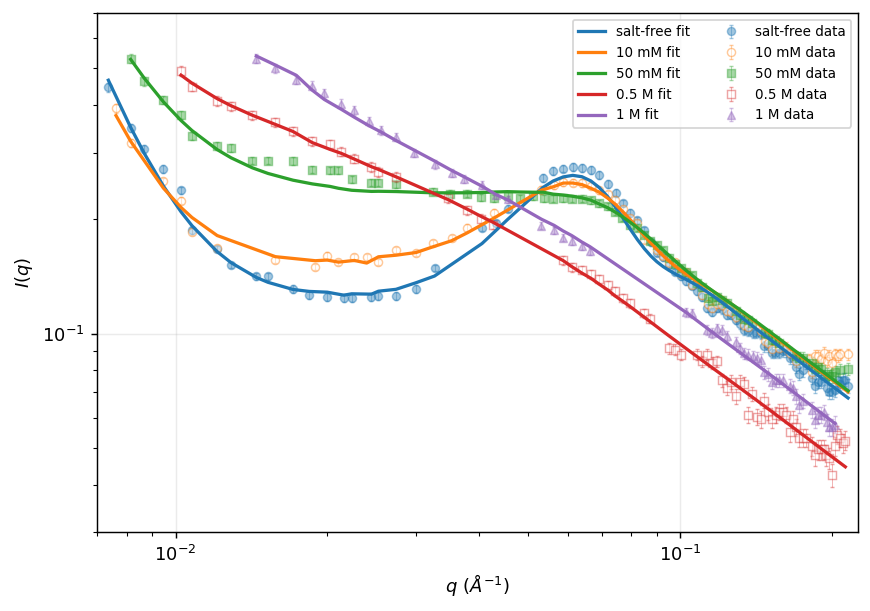

[status] saved output\pecora\pecora_all_observations_and_model_fits.png


In [3]:
fig, ax = plt.subplots(figsize=(6.8, 4.8))

for item in SERIES:
    tag = item["tag"]
    obs = observations[tag]
    fit = fit_curves[tag]
    positive = np.isfinite(obs["I"]) & (obs["I"] > 0.0)
    marker_face = item["color"] if item["filled"] else "white"
    ax.errorbar(
        obs["Q"][positive],
        obs["I"][positive],
        yerr=obs["err"][positive],
        fmt=item["marker"],
        ms=4.5,
        lw=0.45,
        capsize=1.2,
        color=item["color"],
        markerfacecolor=marker_face,
        markeredgewidth=0.8,
        alpha=0.42,
        label=f"{item['label']} data",
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"],
        color=item["color"],
        lw=1.8,
        label=f"{item['label']} fit",
        zorder=10,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(7.0e-3, 2.25e-1)
ax.set_ylim(3.0e-2, 7.0e-1)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout()

COMPARISON_PLOT = OUTPUT_DIR / "pecora_all_observations_and_model_fits.png"
fig.savefig(COMPARISON_PLOT, bbox_inches="tight")
plt.show()
print(f"[status] saved {COMPARISON_PLOT}")


## Fit-parameter summary


In [4]:
FLOATING_PARAMETER_NAMES = (
    "mean_k", "r_sigma_k", "skewness", "k_H_over_k", "b", "scale"
)
DERIVED_PARAMETER_NAMES = (
    "k_H", "p_H", "sigma_H_squared", "alpha_H", "kappa_H", "rho0", "highq_coefficient"
)

print("Pecora fit information map")
print("-" * 108)
print("Floating: " + ", ".join(FLOATING_PARAMETER_NAMES))
print("Derived:  " + ", ".join(DERIVED_PARAMETER_NAMES))
print("-" * 108)
for item in SERIES:
    tag = item["tag"]
    params = fit_parameters[tag]
    anchors = anchor_guesses[tag]
    n_fit = len(fit_curves[tag]["Q"])
    highq_anchor = anchors["highQ_line"]["value_1"]
    lowq_kappa = anchors["lowQ_DAB"]["value_1"]
    print(
        f"{item['label']:>9s}: N_fit={n_fit}, effective fit parameters=6, "
        f"nominal residual dof={n_fit-6}"
    )
    print(
        f"  mean_k={params['mean_k']:.6g}, r_sigma_k={params['r_sigma_k']:.6g}, "
        f"skewness={params['skewness']:.6g}, k_H/k={params['k_H_over_k']:.6g}, "
        f"b={params['b']:.6g}, scale={params['scale']:.6g}"
    )
    print(
        f"  kappa_H={params['kappa_H']:.6g}; low-q DAB anchor kappa={lowq_kappa:.6g}; "
        f"model/anchor={params['kappa_H']/lowq_kappa:.6g}"
    )
    print(
        f"  high-q coefficient model={params['highq_coefficient']:.6g}; "
        f"anchor={highq_anchor:.6g}; model/anchor={params['highq_coefficient']/highq_anchor:.6g}"
    )


Pecora fit information map
------------------------------------------------------------------------------------------------------------
Floating: mean_k, r_sigma_k, skewness, k_H_over_k, b, scale
Derived:  k_H, p_H, sigma_H_squared, alpha_H, kappa_H, rho0, highq_coefficient
------------------------------------------------------------------------------------------------------------
salt-free: N_fit=87, effective fit parameters=6, nominal residual dof=81
  mean_k=0.0364224, r_sigma_k=0.208111, skewness=0.256271, k_H/k=0.0636376, b=-1.58249, scale=32.9078
  kappa_H=0.00113698; low-q DAB anchor kappa=0.006; model/anchor=0.189497
  high-q coefficient model=0.014313; anchor=0.0138959; model/anchor=1.03002
    10 mM: N_fit=71, effective fit parameters=6, nominal residual dof=65
  mean_k=0.0375364, r_sigma_k=0.265961, skewness=0.262334, k_H/k=0.0462988, b=-1.6559, scale=31.0632
  kappa_H=0.000871944; low-q DAB anchor kappa=0.006; model/anchor=0.145324
  high-q coefficient model=0.0148471; anch

## Display all fitted curves on the Pecora 1998 figure

The overlay uses the same linear axis calibration as `data/pecora/digitize_pecora.py`.
The scan is cropped to the printed plot frame and shown in physical `(q, I)` coordinates,
so the fitted curves can be drawn directly on top.


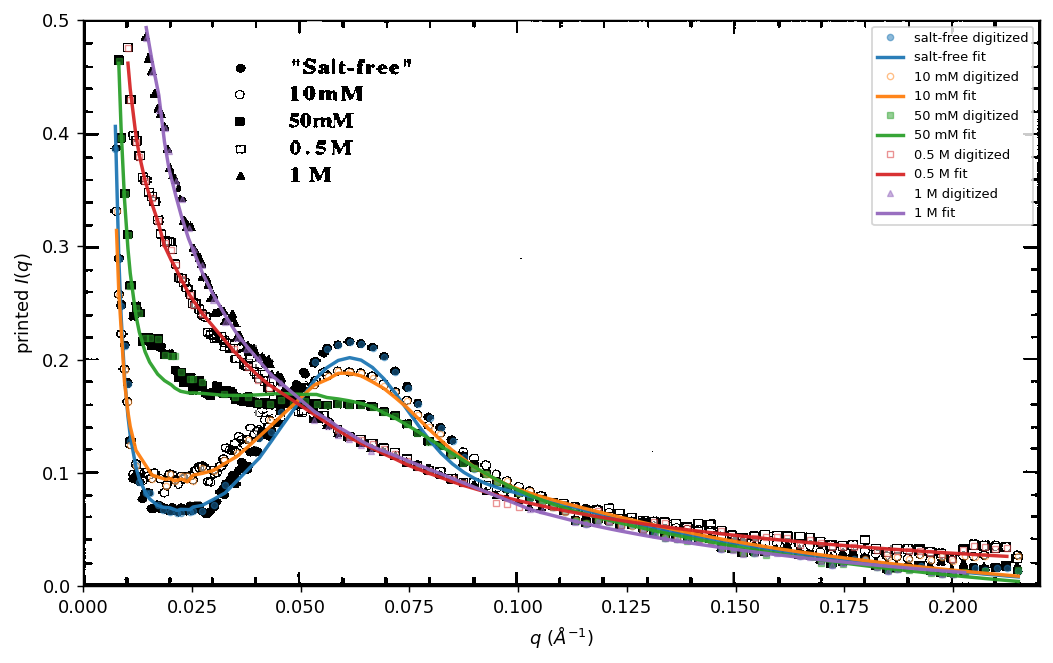

[status] saved output\pecora\pecora_1998_figure_with_all_fits.png


In [5]:
# Axis calibration copied from data/pecora/digitize_pecora.py.
X_LEFT, X_RIGHT = 174.0, 1011.0
Y_TOP, Y_BOTTOM = 125.0, 684.0
Q_MIN, Q_MAX = 0.0, 0.22
I_MIN, I_MAX = 0.0, 0.50

figure_image = plt.imread(DATA_DIR / "pecora_1998_figure.png")
crop = figure_image[int(Y_TOP): int(Y_BOTTOM) + 1, int(X_LEFT): int(X_RIGHT) + 1]

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.imshow(
    crop,
    extent=(Q_MIN, Q_MAX, I_MIN, I_MAX),
    origin="upper",
    aspect="auto",
    interpolation="nearest",
    zorder=0,
)

# Raw digitized points sit in the coordinate system of the printed figure.
# The fitted curves are from the background-corrected data; add back the
# subtracted constant background so they sit on the original printed figure.
for item in SERIES:
    tag = item["tag"]
    raw = raw_observations[tag]
    fit = fit_curves[tag]
    anchors = anchor_guesses[tag]
    background = anchors["subtracted_background"]["value_1"]
    marker_face = item["color"] if item["filled"] else "white"

    ax.plot(
        raw["Q"],
        raw["I"],
        linestyle="none",
        marker=item["marker"],
        markersize=3.5,
        markerfacecolor=marker_face,
        markeredgecolor=item["color"],
        markeredgewidth=0.75,
        alpha=0.50,
        label=f"{item['label']} digitized",
        zorder=4,
    )
    ax.plot(
        fit["Q"],
        fit["I_fit"] + background,
        color=item["color"],
        lw=1.9,
        alpha=0.95,
        label=f"{item['label']} fit",
        zorder=8,
    )

ax.set_xlim(Q_MIN, Q_MAX)
ax.set_ylim(I_MIN, I_MAX)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"printed $I(q)$")
ax.grid(False)
ax.legend(loc="upper right", fontsize=7.2, frameon=True, ncol=1)
fig.tight_layout()

FIGURE_OVERLAY = OUTPUT_DIR / "pecora_1998_figure_with_all_fits.png"
fig.savefig(FIGURE_OVERLAY, bbox_inches="tight")
plt.show()
print(f"[status] saved {FIGURE_OVERLAY}")


## Orientation correlations of the fitted line fields

Following `../rw_line_tcorr.ipynb`, the first panel shows the exact ordered-field signed tangent correlation $K_T^{\rm raw}=M_T/M_J$, with $M_T=2b^2+4bc_z$. The second panel shows the line-density-weighted nematic correlation $K_2=M_2/M_J$, evaluated by conditional Gaussian sampling with the same Jacobian weight used for $M_J$.

Each condition uses its fitted maximum-entropy radial wavevector distribution. Separation is reported as $r k_{\rm eff}$, where $k_{\rm eff}=\sqrt{\langle k^2\rangle}$ is evaluated separately for each fitted spectrum, so all five curves share one dimensionless horizontal axis. Common Sobol seeds reduce sampling noise in their relative comparison.


In [6]:
ORIENTATION_NUM_K_MODES = 2**13
ORIENTATION_N_SAMP = 2**20
ORIENTATION_RANDOM_SEED = 12345
ORIENTATION_X_GRID = np.geomspace(1.0e-3, 60.0, 360)
ORIENTATION_PROGRESS = True

orientation_results = {}

for item in SERIES:
    tag = item["tag"]
    params = fit_parameters[tag]
    k_rng = np.random.default_rng(ORIENTATION_RANDOM_SEED)
    k_sets = rls.make_field_k_sets(
        ORIENTATION_NUM_K_MODES,
        "max_entropy_radial",
        k_rng,
        k0=params["mean_k"],
        r_sigma_k=params["r_sigma_k"],
        distribution_params={"skewness": params["skewness"]},
        shared_k_vectors=True,
        use_qmc_k=True,
        qmc_seed=ORIENTATION_RANDOM_SEED,
    )
    k_radii = rls.k_radii_from_vectors(k_sets.psi1)
    k_eff = np.sqrt(
        3.0 * rls.gradient_variance_from_k_radii(k_radii)
    )
    r_grid = ORIENTATION_X_GRID / k_eff

    # The nematic estimator returns the same conditional M_J needed by
    # the exact signed-correlation normalization, avoiding a duplicate
    # direct-12D Jacobian calculation.
    nematic = rls.compute_nematic_tangent_correlation(
        r_grid,
        k_radii,
        ORIENTATION_N_SAMP,
        use_qmc=True,
        random_seed=ORIENTATION_RANDOM_SEED,
        progress=ORIENTATION_PROGRESS,
    )
    signed = rls.compute_signed_tangent_correlation(
        r_grid,
        k_radii,
        nematic["M_J"],
    )

    result = {
        "r_grid": r_grid,
        "r_k_eff": ORIENTATION_X_GRID.copy(),
        "k_eff": k_eff,
        "M_J": nematic["M_J"],
        "M_T": signed["M_T"],
        "M_2": nematic["M_2"],
        "K_T_raw": signed["K_T_raw"],
        "K_2": nematic["K_2"],
        "K_2_sampled": nematic["K_2_sampled"],
        "K_2_inf_sampled": nematic["K_2_inf_sampled"],
    }
    orientation_results[tag] = result

    data_path = OUTPUT_DIR / f"{tag}_orientation_correlations.npz"
    np.savez(
        data_path,
        **result,
        mean_k=params["mean_k"],
        r_sigma_k=params["r_sigma_k"],
        skewness=params["skewness"],
        num_k_modes=ORIENTATION_NUM_K_MODES,
        n_samp=ORIENTATION_N_SAMP,
        random_seed=ORIENTATION_RANDOM_SEED,
    )
    print(
        f"[orientation] {item['label']:>9s}: k_eff={k_eff:.6g} A^-1, "
        f"K_T_raw(r_min)={result['K_T_raw'][0]:.6g}, "
        f"K_2(r_min)={result['K_2_sampled'][0]:.6g}, "
        f"K_2_inf_sampled={result['K_2_inf_sampled']:.6g}; saved {data_path}"
    )


K_2 direct_12d: 18/360 r values (4.3s)
K_2 direct_12d: 36/360 r values (8.5s)
K_2 direct_12d: 54/360 r values (12.5s)
K_2 direct_12d: 72/360 r values (16.7s)
K_2 direct_12d: 90/360 r values (21.0s)
K_2 direct_12d: 108/360 r values (25.3s)
K_2 direct_12d: 126/360 r values (29.5s)
K_2 direct_12d: 144/360 r values (33.7s)
K_2 direct_12d: 162/360 r values (38.1s)
K_2 direct_12d: 180/360 r values (42.3s)
K_2 direct_12d: 198/360 r values (46.8s)
K_2 direct_12d: 216/360 r values (51.3s)
K_2 direct_12d: 234/360 r values (55.6s)
K_2 direct_12d: 252/360 r values (59.9s)
K_2 direct_12d: 270/360 r values (64.1s)
K_2 direct_12d: 288/360 r values (68.5s)
K_2 direct_12d: 306/360 r values (72.7s)
K_2 direct_12d: 324/360 r values (76.8s)
K_2 direct_12d: 342/360 r values (81.1s)
K_2 direct_12d: 360/360 r values (85.5s)
[orientation] salt-free: k_eff=0.0372045 A^-1, K_T_raw(r_min)=0.999972, K_2(r_min)=0.999999, K_2_inf_sampled=0.000784943; saved output\pecora\pecora_salt_free_orientation_correlations.npz

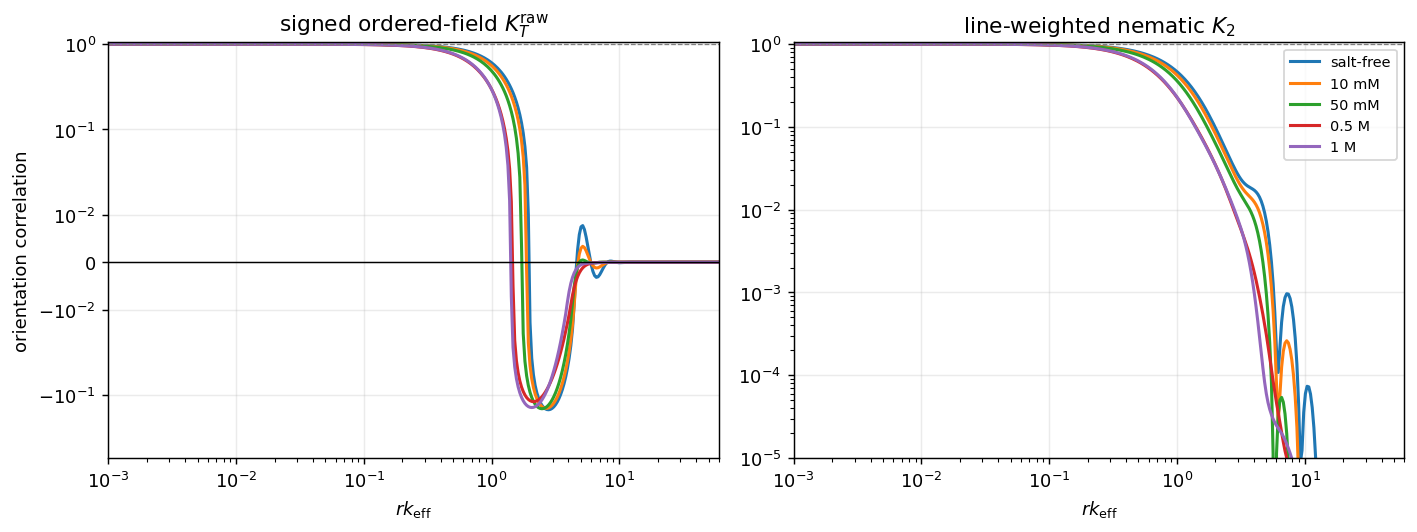

[status] saved output\pecora\pecora_orientation_correlations.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharex=True, sharey=False)

for item in SERIES:
    result = orientation_results[item["tag"]]
    axes[0].semilogx(
        result["r_k_eff"],
        result["K_T_raw"],
        color=item["color"],
        lw=1.7,
        label=item["label"],
    )
    axes[1].semilogx(
        result["r_k_eff"],
        result["K_2"]-result["K_2_inf_sampled"],
        color=item["color"],
        lw=1.7,
        label=item["label"],
    )
    # k2_approx = (result["K_T_raw"]**2)
    # axes[1].semilogx(
    #     result["r_k_eff"],
    #     k2_approx,
    #     color=item["color"],
    #     lw=1.7,
    #     label=item["label"],
    # )

for ax in axes:
    ax.axhline(0.0, color="black", lw=0.8)
    ax.axhline(1.0, color="0.5", lw=0.7, ls="--")
    ax.set_xlim(ORIENTATION_X_GRID[0], ORIENTATION_X_GRID[-1])
    ax.set_xlabel(r"$r k_{\rm eff}$")

axes[0].set_ylabel("orientation correlation")
axes[0].set_title(r"signed ordered-field $K_T^{\rm raw}$")
axes[0].set_yscale("symlog", linthresh=0.01, linscale=0.5)
axes[0].set_ylim(-0.55, 1.05)
axes[1].set_title(r"line-weighted nematic $K_2$")
axes[1].legend(fontsize=8, loc="best")
axes[1].set_yscale("log")
axes[1].set_ylim(0.00001, 1.05)
fig.tight_layout()

ORIENTATION_PLOT = OUTPUT_DIR / "pecora_orientation_correlations.png"
fig.savefig(ORIENTATION_PLOT, bbox_inches="tight")
plt.show()
print(f"[status] saved {ORIENTATION_PLOT}")


## Static 3D renderings with and without heterogeneity

As in `cf_compare_yyw.ipynb`, every Pecora condition is rendered twice: once with its fitted heterogeneous mask and once with `p_H=1` (unmasked). The 1 M condition defines the reference box. For each other condition the lateral and thickness ratios are scaled by $k_H/k_{H,\mathrm{1M}}$, so multiplying those ratios by the physical mask length $1/k_H$ gives the same physical box dimensions for all five conditions.

Pecora does not provide the composition/SLD information used to infer the YYW tube cross-section, so all conditions use one fixed visual tube-radius fraction. This keeps the comparison focused on the fitted line spectrum and heterogeneous mask rather than assigning an unsupported physical tube area.


In [8]:
# RENDER_RANDOM_SEED = 114514
# RENDER_K_LINE = 10.0
# RENDER_NUM_LINE_MODES = 128
# RENDER_NX = 150
# RENDER_NY = 150
# RENDER_NZ = 15
# RENDER_1M_LATERAL_SIZE_OVER_MASK_LENGTH = 25.0
# RENDER_1M_THICKNESS_OVER_MASK_LENGTH = 1.25
# RENDER_LINE_TUBE_RADIUS_FRACTION = 0.0015
# RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K = 10.0
# RENDER_SHOW_MASK_BOUNDARY = False
# RENDER_SHOW_BOX_BOUNDARY = True
# RENDER_SHOW_REJECTED_LINES = False
# RENDER_WINDOW_SIZE = (800, 800)
# RENDER_WINDOW_FILL_FRACTION = 0.95
# RENDER_INITIAL_VIEW = "normal"
# RENDER_SCREENSHOT_SCALE = 3

# REFERENCE_TAG = "pecora_1M"
# visual_k_H = {
#     tag: RENDER_K_LINE * fit_parameters[tag]["k_H_over_k"]
#     for tag in SAMPLE_TAGS
# }
# visual_mask_length = {tag: 1.0 / visual_k_H[tag] for tag in SAMPLE_TAGS}
# ratio_scale = {
#     tag: fit_parameters[tag]["k_H"] / fit_parameters[REFERENCE_TAG]["k_H"]
#     for tag in SAMPLE_TAGS
# }
# render_lateral_ratio = {
#     tag: RENDER_1M_LATERAL_SIZE_OVER_MASK_LENGTH * ratio_scale[tag]
#     for tag in SAMPLE_TAGS
# }
# render_thickness_ratio = {
#     tag: RENDER_1M_THICKNESS_OVER_MASK_LENGTH * ratio_scale[tag]
#     for tag in SAMPLE_TAGS
# }
# physical_mask_length_nm = {
#     tag: 0.1 / fit_parameters[tag]["k_H"]
#     for tag in SAMPLE_TAGS
# }
# physical_lateral_size_nm = {
#     tag: render_lateral_ratio[tag] * physical_mask_length_nm[tag]
#     for tag in SAMPLE_TAGS
# }
# physical_thickness_nm = {
#     tag: render_thickness_ratio[tag] * physical_mask_length_nm[tag]
#     for tag in SAMPLE_TAGS
# }

# for item in SERIES:
#     tag = item["tag"]
#     visual_lateral_size = render_lateral_ratio[tag] * visual_mask_length[tag]
#     visual_thickness = render_thickness_ratio[tag] * visual_mask_length[tag]
#     print(
#         f"[render settings] {item['label']:>9s}: "
#         f"p_H={fit_parameters[tag]['p_H']:.6g}, "
#         f"visual_box=({visual_lateral_size:.6g}, {visual_lateral_size:.6g}, "
#         f"{visual_thickness:.6g}), physical_box="
#         f"({physical_lateral_size_nm[tag]:.6g}, {physical_lateral_size_nm[tag]:.6g}, "
#         f"{physical_thickness_nm[tag]:.6g}) nm"
#     )

# reference_lateral_size_nm = physical_lateral_size_nm[REFERENCE_TAG]
# reference_thickness_nm = physical_thickness_nm[REFERENCE_TAG]
# for tag in SAMPLE_TAGS:
#     assert np.isclose(physical_lateral_size_nm[tag], reference_lateral_size_nm)
#     assert np.isclose(physical_thickness_nm[tag], reference_thickness_nm)
# print("[status] verified: all five render boxes have the same physical dimensions")


In [9]:
# render_results = {}
# unmasked_render_results = {}

# for item in SERIES:
#     tag = item["tag"]
#     params = fit_parameters[tag]
#     common_kwargs = dict(
#         visual_k_line=RENDER_K_LINE,
#         line_k_distribution="max_entropy_radial",
#         line_r_sigma_k=params["r_sigma_k"],
#         line_k_distribution_params={"skewness": params["skewness"]},
#         random_seed=RENDER_RANDOM_SEED,
#         num_line_modes=RENDER_NUM_LINE_MODES,
#         nx=RENDER_NX,
#         ny=RENDER_NY,
#         nz=RENDER_NZ,
#         lateral_size_over_mask_length=render_lateral_ratio[tag],
#         thickness_over_mask_length=render_thickness_ratio[tag],
#         line_tube_radius_fraction=RENDER_LINE_TUBE_RADIUS_FRACTION,
#         min_retained_line_length_over_k=RENDER_MIN_RETAINED_LINE_LENGTH_OVER_K,
#         show_box_boundary=RENDER_SHOW_BOX_BOUNDARY,
#         window_size=RENDER_WINDOW_SIZE,
#         window_fill_fraction=RENDER_WINDOW_FILL_FRACTION,
#         initial_view=RENDER_INITIAL_VIEW,
#         screenshot_scale=RENDER_SCREENSHOT_SCALE,
#     )

#     heterogeneous_path = OUTPUT_DIR / f"{tag}_fit_heterogeneous_common_box.png"
#     heterogeneous = cf.render_fit_heterogeneous_preview(
#         params,
#         output_path=heterogeneous_path,
#         show_mask_boundary=RENDER_SHOW_MASK_BOUNDARY,
#         show_rejected_lines=RENDER_SHOW_REJECTED_LINES,
#         **common_kwargs,
#     )
#     render_results[tag] = heterogeneous
#     heterogeneous.plotter.close()
#     print(
#         f"[status] saved {heterogeneous_path}; p_H={heterogeneous.p_H:.6g}, "
#         f"retained cells={heterogeneous.retained_cells}, "
#         f"retained points={heterogeneous.retained_points}"
#     )

#     unmasked_path = OUTPUT_DIR / f"{tag}_fit_unmasked_common_box.png"
#     unmasked_params = dict(params)
#     unmasked_params["p_H"] = 1.0
#     unmasked = cf.render_fit_heterogeneous_preview(
#         unmasked_params,
#         output_path=unmasked_path,
#         show_mask_boundary=False,
#         show_rejected_lines=False,
#         **common_kwargs,
#     )
#     unmasked_render_results[tag] = unmasked
#     unmasked.plotter.close()
#     print(
#         f"[status] saved {unmasked_path}; p_H={unmasked.p_H:.6g}, "
#         f"line cells={unmasked.retained_cells}, "
#         f"line points={unmasked.retained_points}"
#     )
